**Part 1: Problem Statement**

To develop a predictive system that predicts and classifies an individual's risk of mental health challenges by analyzing occupational, behavioral, and historical factors

In [ ]:
#import necessary libraries
import pandas as pd # for data manipulation and analysis 
import numpy as np# data manipulation and analysis for math operations and arrays 
import matplotlib.pyplot as plt#for data visualization
import seaborn as sns# for data visualization
from sklearn.preprocessing import StandardScaler# standardizing
from sklearn.model_selection import train_test_split# split and train and test data
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report) #perfomance metrics of the model
from sklearn.ensemble import RandomForestClassifier #classification

In [17]:
# load the dataset
mh = pd.read_csv(r"C:\Users\HomePC\Desktop\Mental Health Project\myvenv\templates\Mental Health Dataset.csv")

**Exploratory Data Analysis**

In [18]:
# checking shape
mh.shape

(1999, 17)

The mental health data set has 1999 columns and 17 rows.

In [19]:
# checking head and tail
mh.head(10)

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
5,8/27/2014 11:49,Female,Poland,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Not sure
6,8/27/2014 11:51,Female,Australia,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
7,8/27/2014 11:52,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
8,8/27/2014 12:18,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
9,8/27/2014 12:37,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No


In [20]:
# checking the columns
mh.columns

Index(['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed',
       'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress',
       'Changes_Habits', 'Mental_Health_History', 'Mood_Swings',
       'Coping_Struggles', 'Work_Interest', 'Social_Weakness',
       'mental_health_interview', 'care_options'],
      dtype='object')

In [21]:
mh.dtypes

Timestamp                  object
Gender                     object
Country                    object
Occupation                 object
self_employed              object
family_history             object
treatment                  object
Days_Indoors               object
Growing_Stress             object
Changes_Habits             object
Mental_Health_History      object
Mood_Swings                object
Coping_Struggles           object
Work_Interest              object
Social_Weakness            object
mental_health_interview    object
care_options               object
dtype: object

The data types are objects, it generally means that the column contains non-numeric data, such as
Textual strings (where we have "Yes", "No", "High", "Low", "Female"), categorical variables not yet converted to a numeric format, and even mixed types such  a mix of strings and numbers.

In [22]:
# statistical summary
mh.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,1999,1999,1999,1999,1948,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999
unique,118,1,12,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 14:13,Female,United States,Student,No,Yes,Yes,1-14 days,Yes,Maybe,No,Medium,Yes,No,Maybe,No,Yes
freq,34,1999,1359,847,1833,1203,1390,910,1394,910,1089,1089,1031,910,847,1801,796


**Data Preprocessing**

In [23]:
# checking missing values
mh.isnull().sum()

Timestamp                   0
Gender                      0
Country                     0
Occupation                  0
self_employed              51
family_history              0
treatment                   0
Days_Indoors                0
Growing_Stress              0
Changes_Habits              0
Mental_Health_History       0
Mood_Swings                 0
Coping_Struggles            0
Work_Interest               0
Social_Weakness             0
mental_health_interview     0
care_options                0
dtype: int64

From the data set, only self-emplpyed column has 51 missing values

In [24]:

# Replace missing values with 'Unknown'
mh['self_employed'] = mh['self_employed'].replace('', np.nan).fillna('Unknown')


We are replacing the missing values using unknown to keep the information intact because someone could have skipped that part for a reason. Using model would mean i am assuming that the missing values are the majority. 

In [25]:
# rechecking missing values
mh.isnull().sum()

Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64

In [26]:
# Drop timestamp
mh.drop(columns=['Timestamp'], inplace=True)

we are droppingg the column timestamp and inplace true means the operation is done directly without needing to assign it back. It just records the date and time when the entry was made so it doesnt have a predictive value for determining mental health challenges.

In [27]:
#Dropping country
print(mh['Country'].value_counts())
country_freq = mh['Country'].value_counts(normalize=True)
mh['Country_encoded'] = mh['Country'].map(country_freq)
mh = mh.drop('Country', axis=1)

Country
United States     1359
United Kingdom     261
Canada             148
Australia           66
Sweden              34
Ireland             32
Poland              17
South Africa        17
New Zealand         17
Netherlands         16
India               16
Belgium             16
Name: count, dtype: int64


Encoding and droping will ensure the country information is kept in numerical format and the machine learning model will detect patterns related to geographical trends. Freq encoding converts categorical variabkes to numerical through replacing each category with with how it appears in a dataset.

In [28]:


# Create mapping dictionaries for each categorical column
mappings = {
    'Gender': {'Female': 0, 'Male': 1, 'Other': 2},
    'Occupation': {
        'Corporate': 0,
        'Student': 1,
        'Business': 2,
        'Housewife': 3
    },
     'self_employed': {'No': 0, 'Yes': 1, 'Unknown': 2},
    'family_history': {'No': 0, 'Yes': 1},
    'treatment': {'No': 0, 'Yes': 1},
    'Days_Indoors': {
        '1-14 days': 0,
        '15-30 days': 1,
        '31-60 days': 2,
        'Go out Every day': 3,
        'More than 2 months': 4
    },
    'Growing_Stress': {'No': 0, 'Yes': 1},
    'Changes_Habits': {'No': 0, 'Yes': 1, 'Maybe': 2},
    'Mental_Health_History': {'No': 0, 'Yes': 1},
    'Mood_Swings': {'Low': 0, 'Medium': 1, 'High': 2},
    'Coping_Struggles': {'No': 0, 'Yes': 1},
    'Work_Interest': {'No': 0, 'Yes': 1, 'Maybe': 2},
    'Social_Weakness': {'No': 0, 'Yes': 1, 'Maybe': 2},
    'mental_health_interview': {'No': 0, 'Yes': 1, 'Maybe': 2},
    'care_options': {'No': 0, 'Yes': 1, 'Not sure': 2}
}

# Apply the mappings to each column
for column in mappings:
    if column in mh.columns:
        mh[column] = mh[column].map(mappings[column])


We need this because machine learning understands numerical data hence the need to change the data from objects to numerics. Mappings are container objects that store data in key-value pairs, where each unique key is associated with a specific value.They allow for efficient retrieval of values based on their corresponding keys. For us, we have nominal and binary categories.

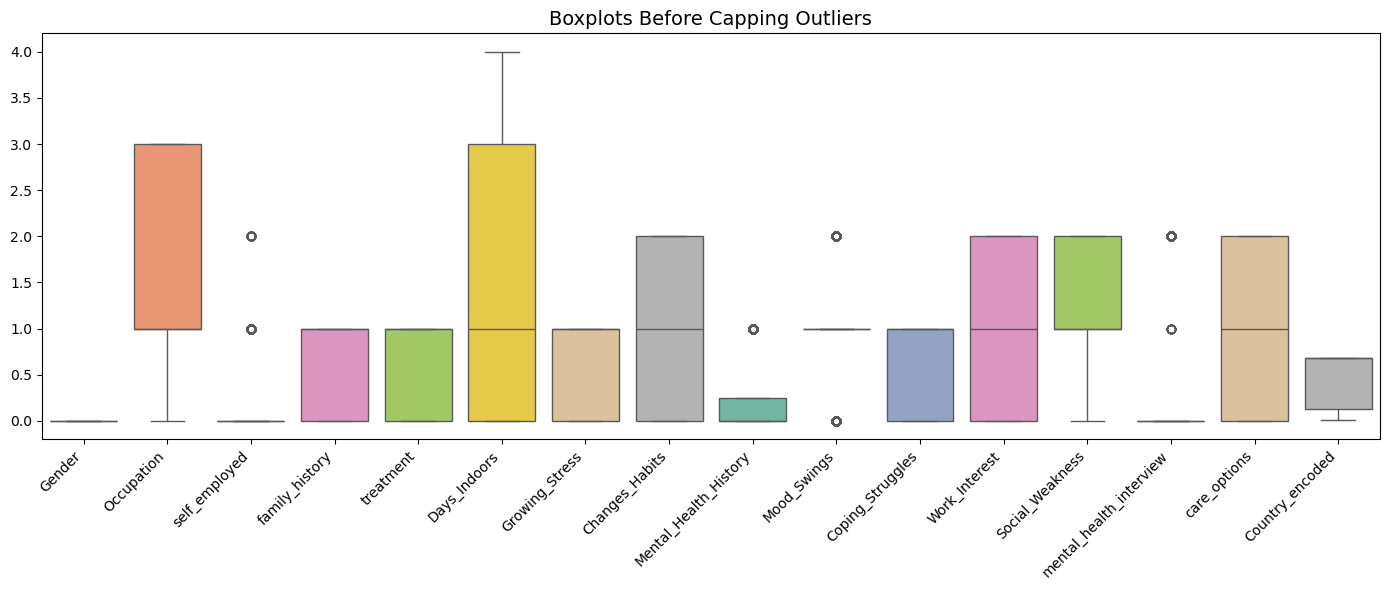

In [29]:
#checking for outliers 
numeric_cols = mh.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(14, 6))
sns.boxplot(data=mh[numeric_cols], palette='Set2')
plt.title("Boxplots Before Capping Outliers", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create a copy to preserve original data
mh_capped = mh.copy()


As we see from the, which shows the distribution and spread of each variable. Outliers appear as individual dots outside the whiskers. For example, self_employed, Mood_Swings contain several outliers. Features like Days_Indoors and Occupation also have wide spreads, suggesting variability or skewness in those values. 

The capping is a data preprocessing technique whcih entails limiting the extreme outliers to a reasonable maximum and minimum rather than removing them. we dint want to loose the rows with valuable information 

In [30]:
# Removing outliers using IQR

for col in numeric_cols:
    Q1 = mh[col].quantile(0.25)
    Q3 = mh[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
 # Cap values instead of dropping rows
    mh_capped[col] = np.where(mh_capped[col] < lower_bound, lower_bound, mh_capped[col])
    mh_capped[col] = np.where(mh_capped[col] > upper_bound, upper_bound, mh_capped[col])
    




We applied the capping logic to the numerical features in the dataset by looping , and calculate the 25th and 75th percentile. Then compute the IQR which is the spread of the 50 percent of the values to identify outliers. then set the threshold where lower bound menas values which are too low while upper bound are too high. Then we capped any values outside the bounds to replace any value in the lower biund and upper bound. so rather than removing, we limit (cap) extreme values to reduce their impacts. 

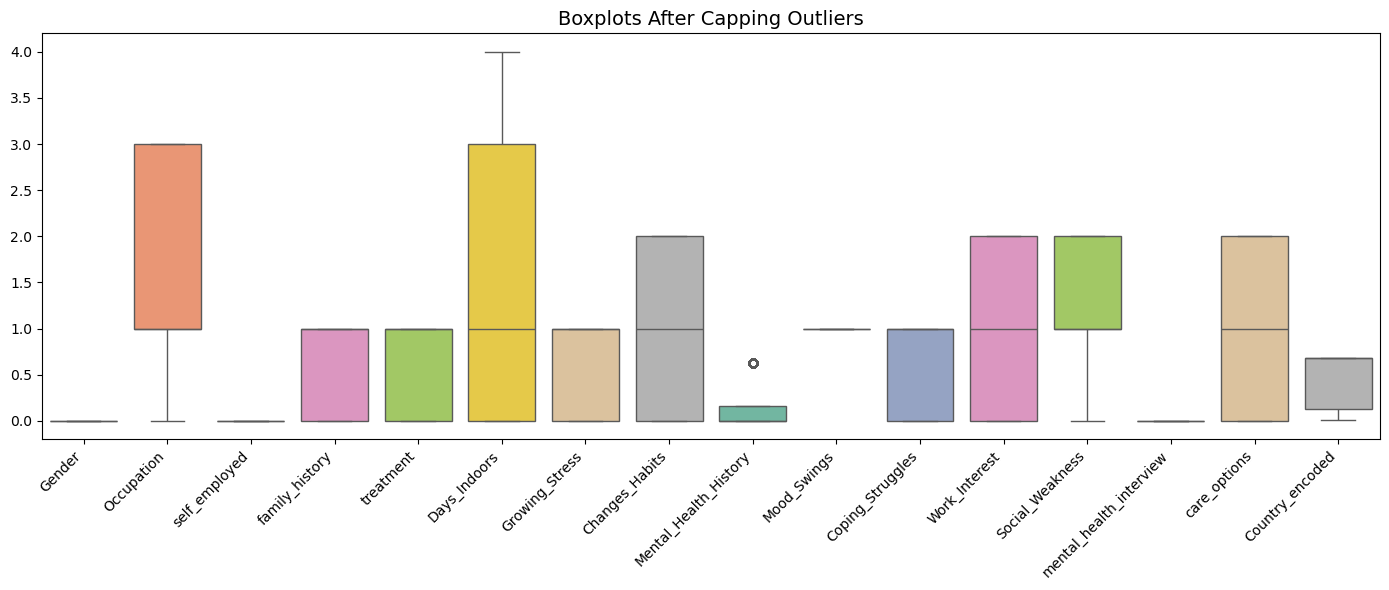

In [31]:
# Rechecking for outliers 
plt.figure(figsize=(14, 6))
sns.boxplot(data=mh_capped[numeric_cols], palette='Set2')
plt.title("Boxplots After Capping Outliers", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

After the applicarion of the IQR method to remove outliers, we can see that, there are no isolated dots beyond the whiskers, meaning extreme values have been excluded. Further, there is a more compact interquartile range (box width) in features like Days_Indoors and Occupation, indicating less variability.

We can also see a cleaner distributions in variables such as self_employed, Mood_Swings, and care_options, where outliers previously existed.

Overall the IQR this improves the dataset quality for modeling by reducing noise from extreme values which could have affected the model accuracy and perfomance.

In [32]:
#Creating target varible where 0 mean no mental health challenge and 1 means mental health challenge is present
condition_indicators = [
    (mh['treatment'] == 1),   # Seeking treatment
    (mh['Coping_Struggles'] == 1),   # Difficulty coping
    (mh['Mental_Health_History'] == 1), # Previous history
    (mh['Growing_Stress'] == 1), # Increasing stress
    (mh['family_history'] == 1), # Family history
    (mh['Changes_Habits'] == 1),  # Habit changes
    (mh['Mood_Swings'] == 1), # Significant mood swings
    (mh['Days_Indoors'] == 1),  # Prolonged isolation
    (mh['Work_Interest'] == 0), # Lost interest in work
    (mh['care_options'].isin(['No', 'Not sure']))  # Lack of care options
]

# Count how many indicators are present for each person
mh['mental_health_indicators'] = sum(condition_indicators)  # Sum of True conditions

# Define target - at least 4 indicators needed to classify as mental health challenge
mh['mental_health_challenge'] = (mh['mental_health_indicators'] >= 4).astype(int)


In [33]:
mh.head()

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Country_encoded,mental_health_indicators,mental_health_challenge
0,0,0.0,2,0,1,0,1.0,0,1.0,1,0,0,1,0,2,0.67984,5,1
1,0,0.0,2,1,1,0,1.0,0,1.0,1,0,0,1,0,0,0.67984,6,1
2,0,0.0,2,1,1,0,1.0,0,1.0,1,0,0,1,0,1,0.67984,6,1
3,0,0.0,0,1,1,0,1.0,0,1.0,1,0,0,1,2,1,0.67984,6,1
4,0,0.0,0,1,1,0,1.0,0,1.0,1,0,0,1,0,1,0.67984,6,1


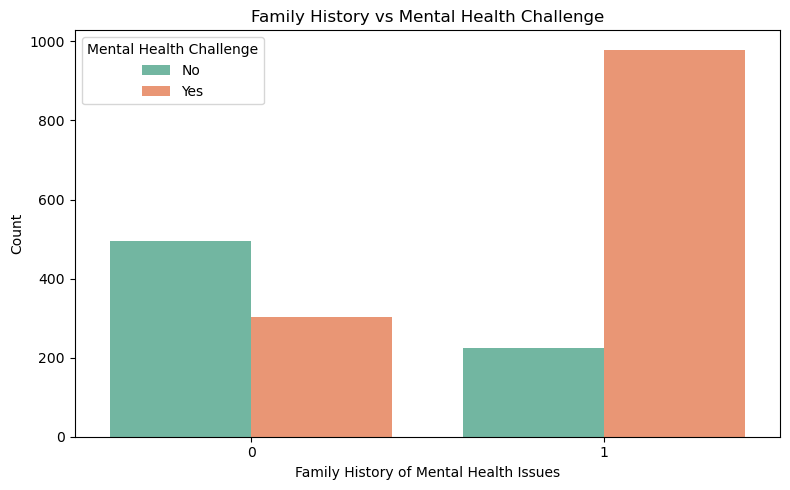

In [34]:
#visualizing plot
plt.figure(figsize=(8, 5))
sns.countplot(data=mh, x='family_history', hue='mental_health_challenge', palette='Set2')
plt.title('Family History vs Mental Health Challenge')
plt.xlabel('Family History of Mental Health Issues')
plt.ylabel('Count')
plt.legend(title='Mental Health Challenge', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()



We can conclude that, respondents who have no family history of mental health issues are less likely to report mental health challenges, while individuals with a family history tend to report mental health challenge. This suggest that there exists a strong correlationneween  family history and personal mental health struggles.

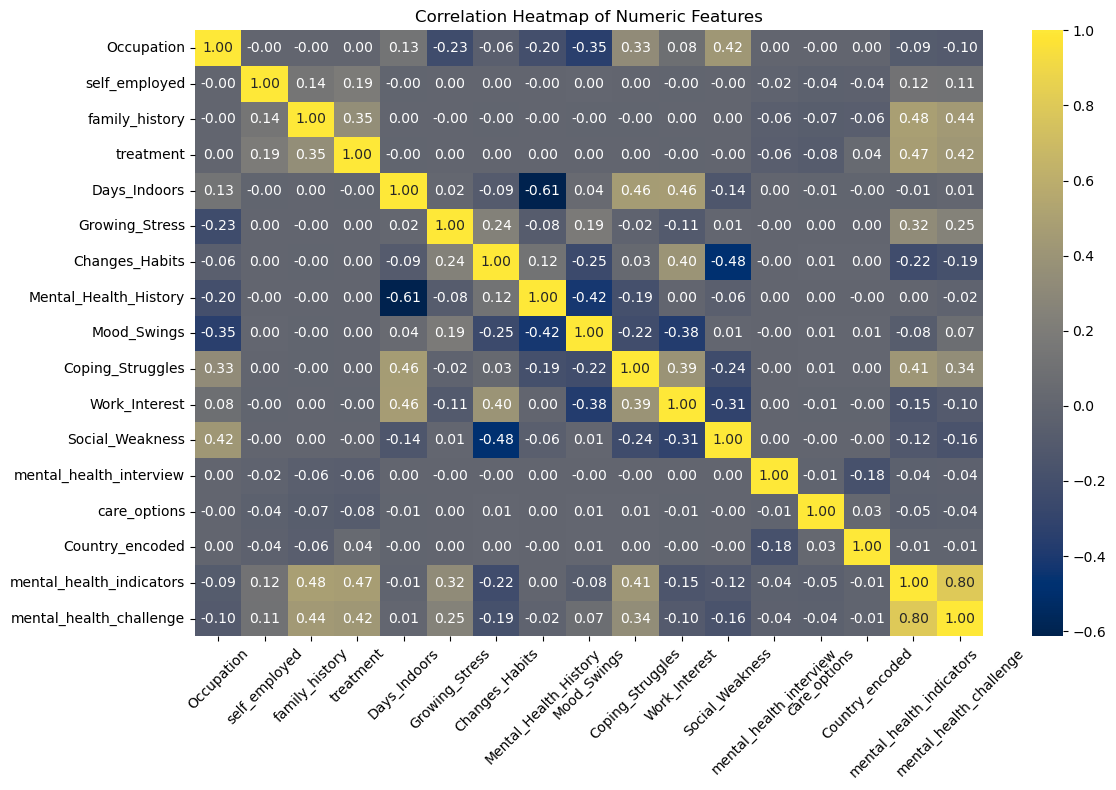

In [35]:
# correlation analysis using heatmap
mh = mh.loc[:, mh.nunique() > 1] # removes columns which have only one unique value hence cannot be correlated 
correlation_matrix = mh.corr(numeric_only=True)# calculates cm for onl numeric columms 
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='cividis', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From the heatmap we can see that the features with the strongest correlations with the target includes coping struggles which means people who struggle with coping mechanisms tend to likely report mental health challenges, treatment also has a high correlation of 0.46 whoch means seeking treatment is moderately associated to mental health challenges , the third feature is occupation which implies that some occupations correlate with high mental health challenges. However, features such as growing stress, mood swings and social weaknes are negatively correlated with the target variable, Including the when predicting would lead to misclassification or noise.

**Model Deployment**

In [36]:
# defining features
features = [
    'Occupation', 'family_history', 'care_options',
    'Mental_Health_History', 'Work_Interest', 'Mood_Swings',
    'Days_Indoors', 'Changes_Habits',
]



In [37]:
# define target and feature
x = mh[features]
y = mh['mental_health_challenge']

In [38]:
# train and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
#create and train the model
rf_model=RandomForestClassifier(n_estimators=500,max_depth=6,random_state=42)
rf_model.fit(x_train,y_train)


RandomForestClassifier(class_weight='balanced')

The n estimators are 500 decision trees in the forest as more trees improve the accuracy. the max depth of 6 means that the true will grow to a maximum depth of 6. The random forest was the best since it combines several decision trees to enhance accuracy and reduce overfitting. Further it helps to understand which feature has the most influence on model output. 

In [41]:
#Make the prediction
y_pred=rf_model.predict(x_test)

In [42]:
#evaluate the model
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy of the model is {accuracy:.2f}")

Accuracy of the model is 0.93


[[138  18]
 [ 11 233]]
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       156
           1       0.93      0.95      0.94       244

    accuracy                           0.93       400
   macro avg       0.93      0.92      0.92       400
weighted avg       0.93      0.93      0.93       400



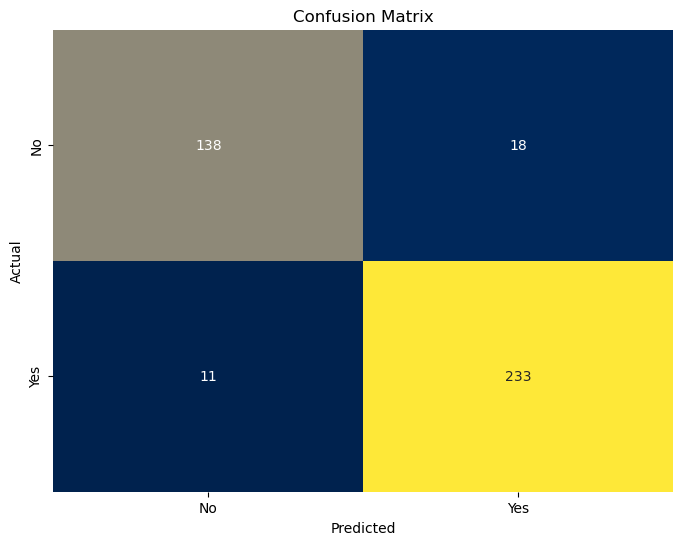

In [43]:
# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(classification_report(y_test, y_pred))

# confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

From the classification matrix, the accuracy of 0.93 shows that 93 percent of all predictions were correct. For the class 0, the model attained a 93 percent precision and recall of 88 which means the actual class of 0s were correctly classified. For class 1, the precision was 93 percent and a recall of 95.

From the confusion matrix, the model correctly classified 138 cases where there was no mental health challenges and wrongly classified 18 cases as having a challenge (Type 1 error). The model also correctly classified 233 cases where mental heakth challenges existed and falsely classified 11 cases.  This means our model is good at detecting true positives and actual cases which is seen in the low false negative.:

In [44]:
#feature importance
feature_importance=rf_model.feature_importances_
feature_df=pd.DataFrame({'Feature':features,'Importance':feature_importance})
sorted_feature=feature_df.sort_values(by='Importance',ascending=False)
print("Top 10 Feature_Importance:")
print(sorted_feature.head(10))

Top 10 Feature_Importance:
                 Feature  Importance
1         family_history    0.339950
0             Occupation    0.167889
5            Mood_Swings    0.116860
4          Work_Interest    0.104598
6           Days_Indoors    0.101610
7         Changes_Habits    0.096867
2           care_options    0.037328
3  Mental_Health_History    0.034898


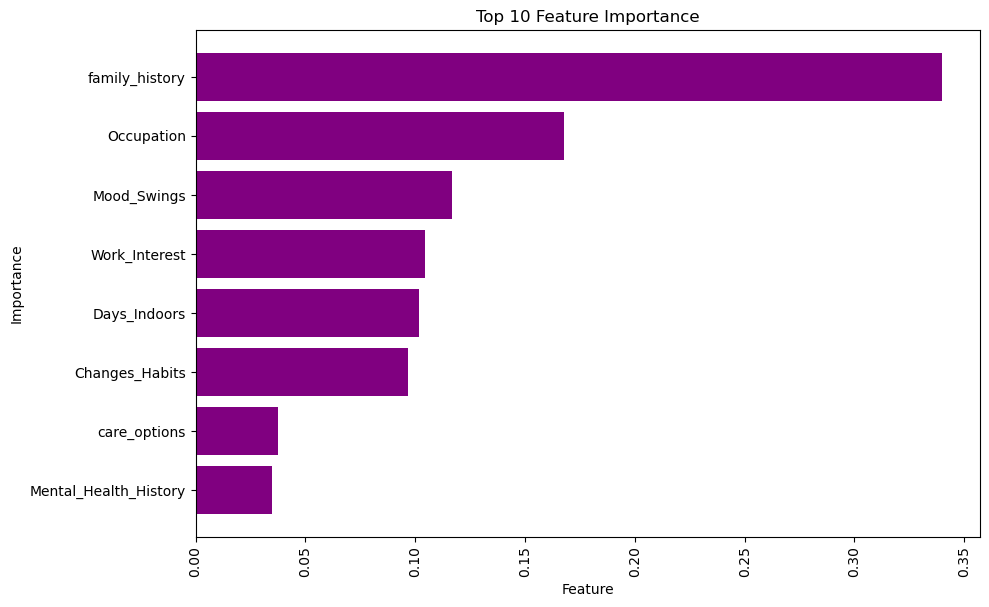

In [45]:
# plot the feature importance of the top 10
plt.figure(figsize=(10,6))
top_features = sorted_feature.head(10).iloc[::-1]
plt.barh(top_features['Feature'],top_features['Importance'], color="purple")
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

This above bar showcases feature importance starting with most important feature to the tenth features. It implies that the model prioritises occupation and days-indoors as the leading predictors of mental health challenges which means work envt and isolation impacts the outcomes. on the other hand, family history and mental health history are relevant but are less dominant.

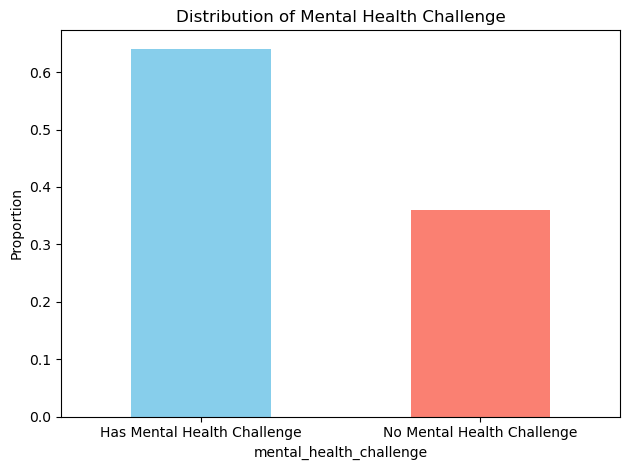

In [46]:
# Check label distribution with custom bar colors
mh['mental_health_challenge'].value_counts(normalize=True).plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title('Distribution of Mental Health Challenge')
plt.xticks(
    ticks=[0, 1],
    labels=['Has Mental Health Challenge', 'No Mental Health Challenge'],
    rotation=0
)
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()


From the bar above, the model most cases (approximately 65pc) did not have mental health challenges and those who had challenges were about 35 pc.

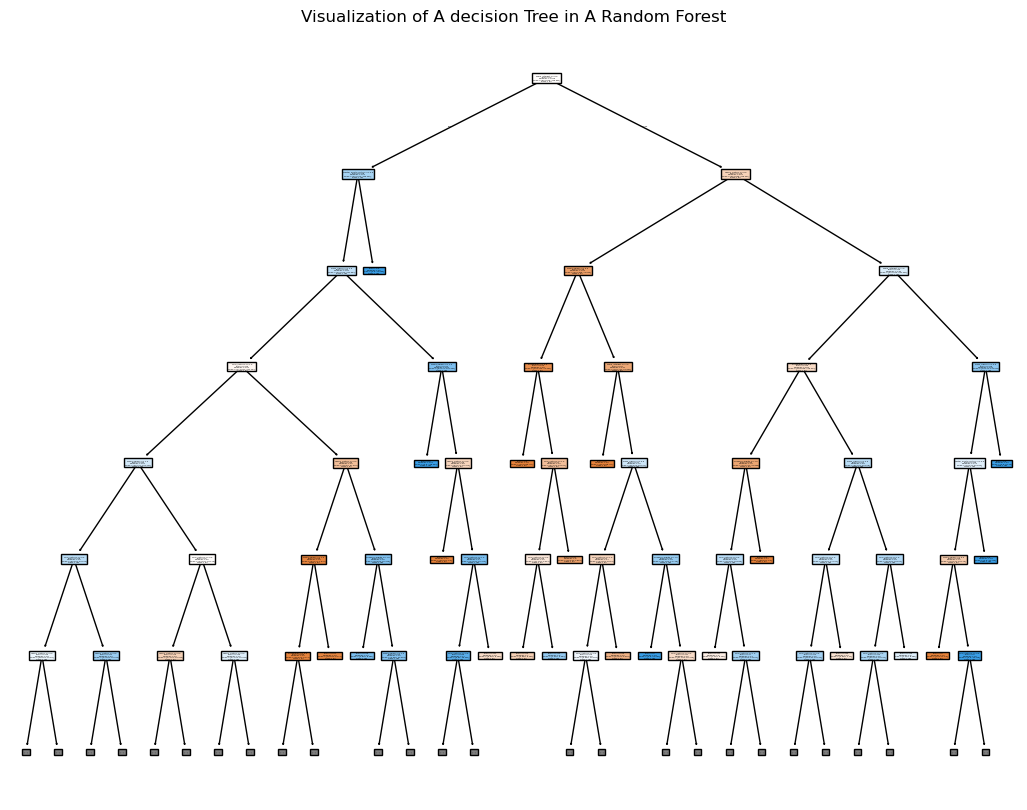

In [ ]:
# visualize the decision tree with max_depth=3
from sklearn.tree import plot_tree #visualize the structure of a trained decision tree model.
feature_names=features
class_names=['No','Yes']
plt.figure(figsize=(13,10))
plot_tree(rf_model.estimators_[0],max_depth=6,filled=True,feature_names=feature_names,class_names=class_names)
plt.title('Visualization of A decision Tree in A Random Forest')
plt.show()

From the decision tree logic, the first split of moood swings less than or equal to 1.5 where if true, it checks majority class as yes and when false it predicts no. The family history and care options refine the predictions further with Yes likely incase family history is present

In [48]:
# saving the model
import pickle
with open('mental_health_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

pickle is a module for saving and loading objects. then we open the file name called  mental health model as wb which is write binary to ensure the data is exactly preserved as it is in the memory. scaler saves the standardscaler object used to training data. It is necessary to save this because any new data needs to be scaled with the same paraments learned when training